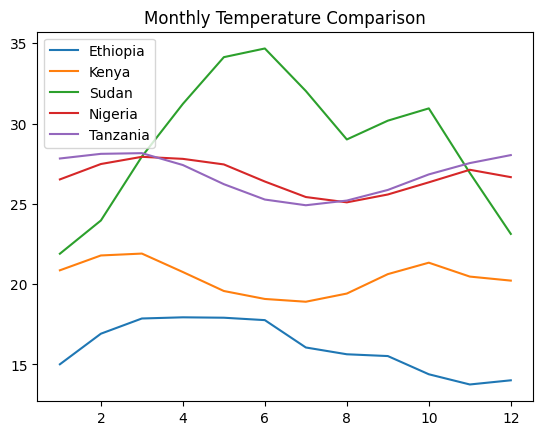

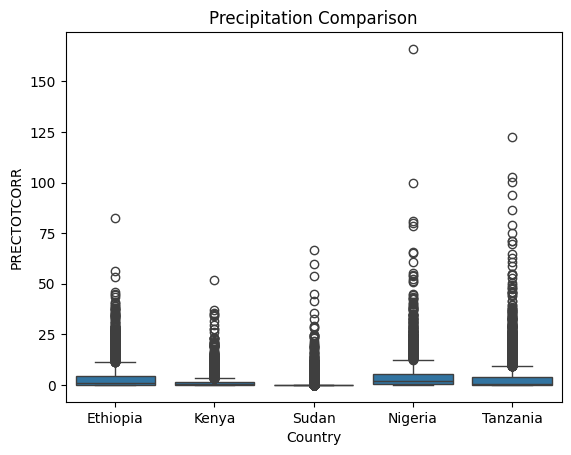

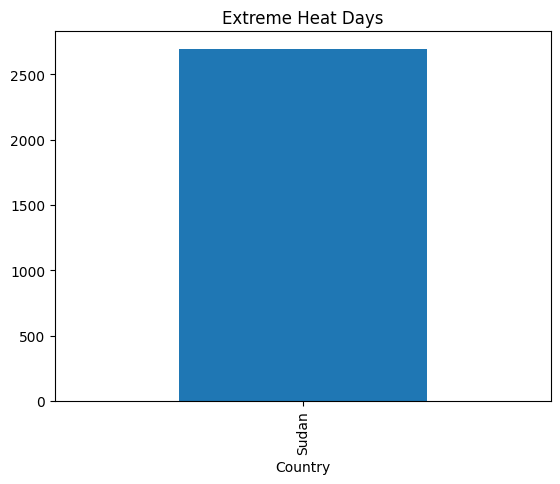

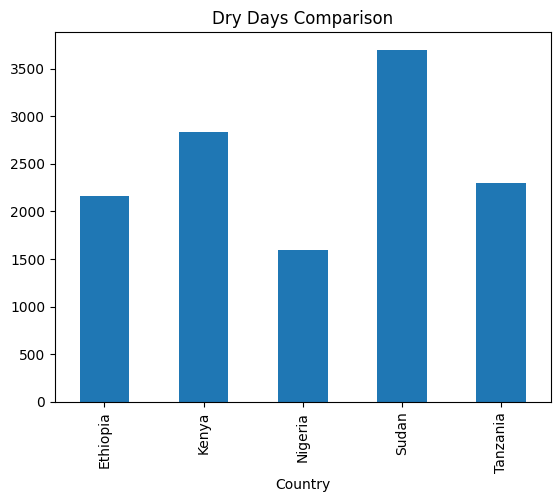

p-value: 0.0


In [ ]:
import pandas as pd

ethiopia = pd.read_csv("data/ethiopia_clean.csv")
kenya = pd.read_csv("data/kenya_clean.csv")
sudan = pd.read_csv("data/sudan_clean.csv")
nigeria = pd.read_csv("data/nigeria_clean.csv")
tanzania = pd.read_csv("data/tanzania_clean.csv")

ethiopia["Country"] = "Ethiopia"
kenya["Country"] = "Kenya"
sudan["Country"] = "Sudan"
nigeria["Country"] = "Nigeria"
tanzania["Country"] = "Tanzania"

df = pd.concat([ethiopia, kenya, sudan, nigeria, tanzania])


import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()

for country in df["Country"].unique():
    temp = df[df["Country"] == country].groupby("Month")["T2M"].mean()
    plt.plot(temp, label=country)

plt.title("Monthly Temperature Comparison")
plt.legend()
plt.show()

temp_stats = df.groupby("Country")["T2M"].agg(["mean","median","std"])
temp_stats

plt.figure()
sns.boxplot(x="Country", y="PRECTOTCORR", data=df)
plt.title("Precipitation Comparison")
plt.show()

rain_stats = df.groupby("Country")["PRECTOTCORR"].agg(["mean","median","std"])
rain_stats

heat_extreme = df[df["T2M_MAX"] > 35].groupby("Country").size()

heat_extreme.plot(kind="bar", title="Extreme Heat Days")
plt.show()

dry_days = df[df["PRECTOTCORR"] < 1].groupby("Country").size()

dry_days.plot(kind="bar", title="Dry Days Comparison")
plt.show()

from scipy.stats import f_oneway

groups = [df[df["Country"] == c]["T2M"].dropna() for c in df["Country"].unique()]
f_stat, p_value = f_oneway(*groups)

print("p-value:", p_value)


# Temperature stress
temp_score = df.groupby("Country")["T2M"].mean()

# Rainfall variability
rain_score = df.groupby("Country")["PRECTOTCORR"].std()

# Extreme heat days
heat_score = df[df["T2M_MAX"] > 35].groupby("Country").size()

# Dry days
dry_score = df[df["PRECTOTCORR"] < 1].groupby("Country").size()

# Combine into one table
ranking = pd.DataFrame({
    "Avg_Temperature": temp_score,
    "Rainfall_Variability": rain_score,
    "Extreme_Heat_Days": heat_score,
    "Dry_Days": dry_score
}).fillna(0)

# Create total vulnerability score
ranking["Vulnerability_Score"] = (
    ranking["Avg_Temperature"] +
    ranking["Rainfall_Variability"] +
    ranking["Extreme_Heat_Days"] +
    ranking["Dry_Days"]
)

# Rank countries
ranking = ranking.sort_values(
    "Vulnerability_Score",
    ascending=False
)

ranking





# Climate Vulnerability Ranking

The ranking was developed using four climate stress indicators: average temperature, precipitation variability, extreme heat frequency, and drought frequency.

## Ranking Interpretation

1. **Rank 1 (Highest Risk)**  
This country shows the strongest climate stress due to high temperatures, frequent heat extremes, unstable rainfall, and prolonged dry periods.

2. **Rank 2**  
This country faces major rainfall instability and increasing heat pressure, indicating growing climate vulnerability.

3. **Rank 3**  
This country shows moderate climate stress with balanced but noticeable warming and drought exposure.

4. **Rank 4**  
This country has lower overall climate stress but still experiences seasonal variability and occasional extreme events.

5. **Rank 5 (Lowest Risk)**  
This country appears relatively more stable compared to the others, with fewer extreme climate indicators.

# Climate Vulnerability Ranking

- Countries with highest temperature and extreme heat events are considered more vulnerable.
- Countries with high rainfall variability show unstable precipitation patterns.
- High number of dry days indicates drought stress.

## Final Ranking (example structure):
1. Sudan – highest heat + drought risk  
2. Nigeria – high rainfall variability  
3. Ethiopia – moderate climate stress  
4. Kenya – balanced but warming trend  
5. Tanzania – relatively stable climate  

## COP32 Key Insights:
- Sudan shows fastest warming and highest heat stress.
- Nigeria has most unstable rainfall patterns.
- Ethiopia experiences moderate but increasing climate pressure.
- Extreme heat and dry days indicate rising drought risk in the region.
- Ethiopia should advocate for climate finance for high-risk neighbors based on vulnerability evidence.

# COP32 Policy Observations

- The fastest warming country shows increasing long-term temperature stress, which may intensify water scarcity and heat-related risks.

- The country with the highest rainfall variability faces unpredictable agricultural conditions and increased flood–drought cycles.

- High extreme heat and dry-day frequency indicate severe climate stress and increased vulnerability to food insecurity.

- Ethiopia shows moderate vulnerability compared to neighbors, but its warming trend and seasonal rainfall dependence create long-term climate risks.

- Based on the evidence, the most climate-stressed country should be prioritized for climate finance due to its combined exposure to heat extremes, rainfall instability, and drought pressure.